# Advanced Plotting Libraries

## Advanced Pandas Visualisation

### Enhancing Pandas built-in plots

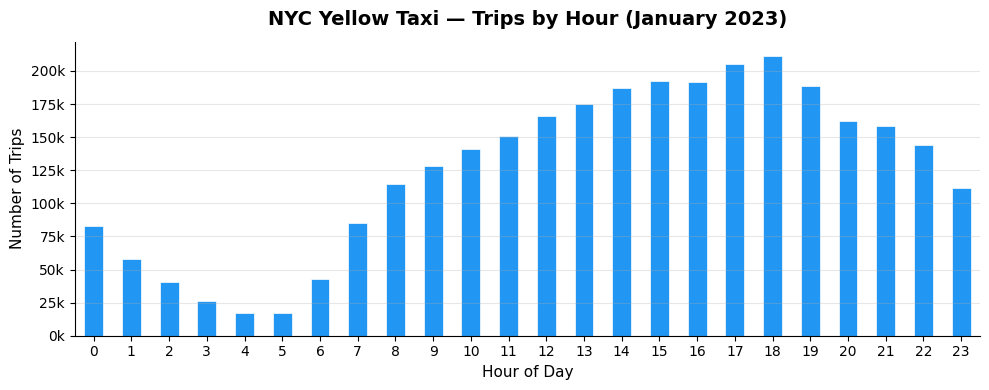

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "trip_distance", "payment_type"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"] = df["tpep_pickup_datetime"].dt.hour

# Hourly trip volume
hourly = df.groupby("hour").size().rename("n_trips")

fig, ax = plt.subplots(figsize=(10, 4))
hourly.plot(
    kind="bar", ax=ax,
    color="#2196F3", edgecolor="white", linewidth=0.5
)
ax.set_title("NYC Yellow Taxi — Trips by Hour (January 2023)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Hour of Day", fontsize=11)
ax.set_ylabel("Number of Trips", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k")
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/taxi_hourly_trips.png", dpi=150)
plt.show()

### Custom styling and theming

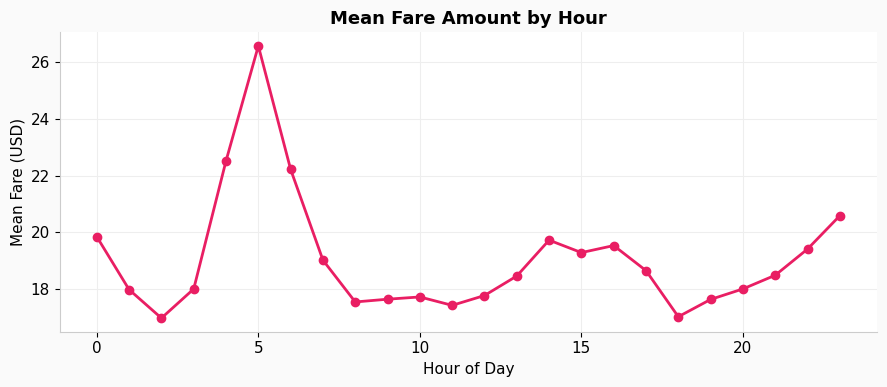

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

STYLE = {
    "figure.facecolor":  "#FAFAFA",
    "axes.facecolor":    "#FFFFFF",
    "axes.edgecolor":    "#CCCCCC",
    "axes.grid":         True,
    "grid.color":        "#EEEEEE",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "lines.linewidth":   2.0,
}

with mpl.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(9, 4))
    df.groupby("hour")["fare_amount"].mean().plot(
        ax=ax, marker="o", color="#E91E63"
    )
    ax.set_title("Mean Fare Amount by Hour")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Mean Fare (USD)")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/mean_fare_amount_hour.png", dpi=150)
    plt.show()

### Combining multiple plots

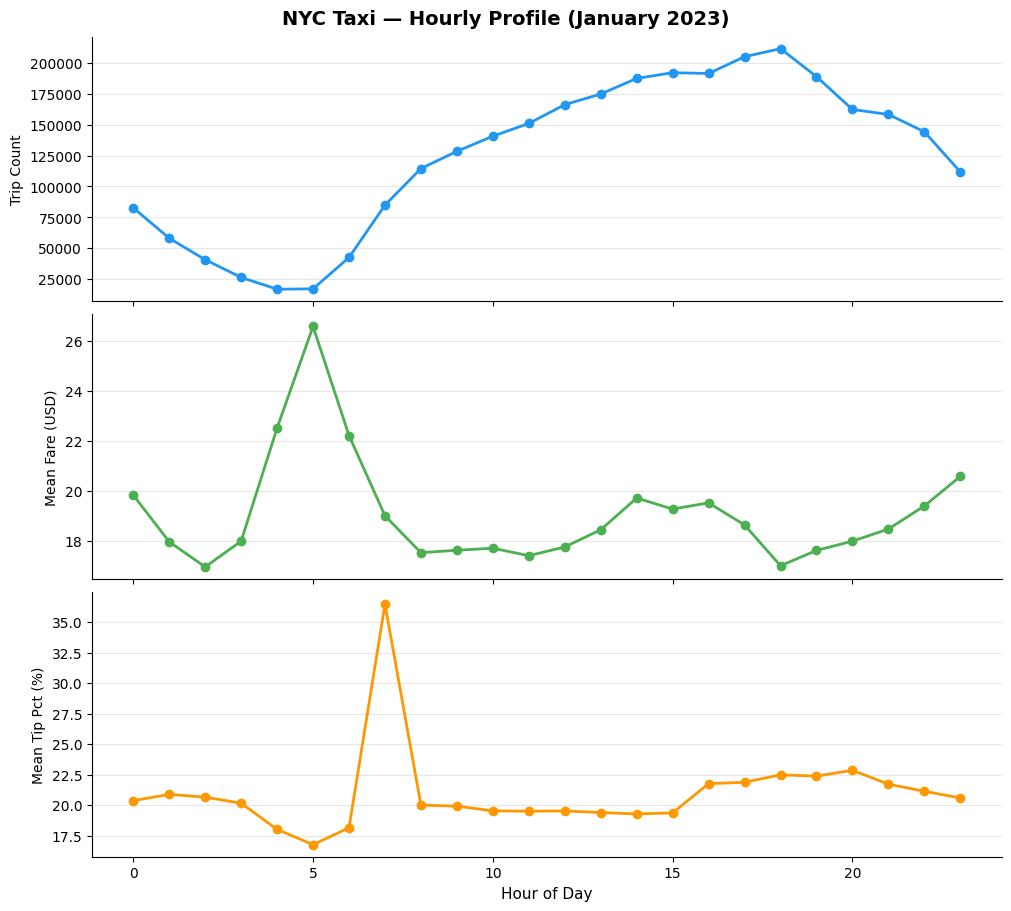

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "tip_amount", "trip_distance"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"]    = df["tpep_pickup_datetime"].dt.hour
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"] * 100).round(1)

hourly = df.groupby("hour").agg(
    n_trips    =("fare_amount", "count"),
    avg_fare   =("fare_amount", "mean"),
    avg_tip_pct=("tip_pct",     "mean"),
)

fig, axes = plt.subplots(3, 1, figsize=(10, 9),
                          sharex=True, constrained_layout=True)

metrics = [
    ("n_trips",     "Trip Count",       "#2196F3"),
    ("avg_fare",    "Mean Fare (USD)",   "#4CAF50"),
    ("avg_tip_pct", "Mean Tip Pct (%)", "#FF9800"),
]

for ax, (col, label, color) in zip(axes, metrics):
    hourly[col].plot(ax=ax, marker="o", color=color, linewidth=2)
    ax.set_ylabel(label, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Hour of Day", fontsize=11)
fig.suptitle("NYC Taxi — Hourly Profile (January 2023)",
             fontsize=14, fontweight="bold")
plt.savefig("../outputs/taxi_hourly_profile.png", dpi=150)
plt.show()

### Handling large datasets efficiently

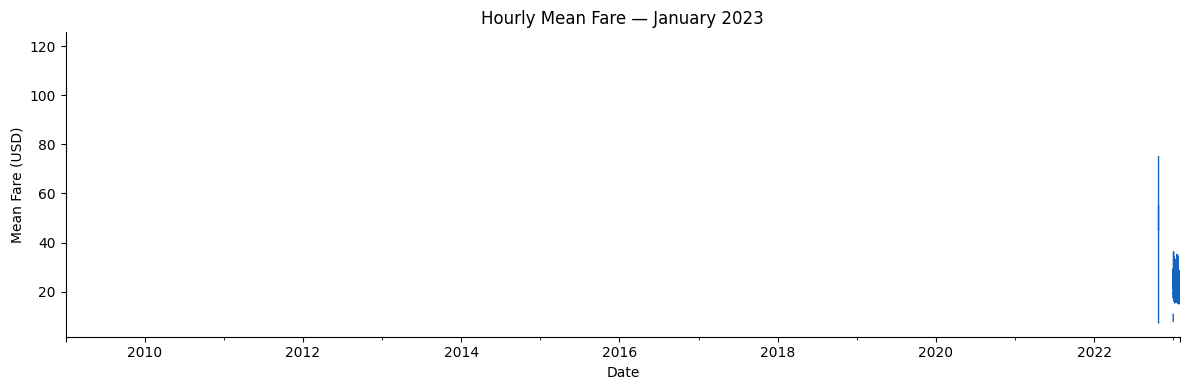

Raw rows: 3,040,607 → resampled: 123,458


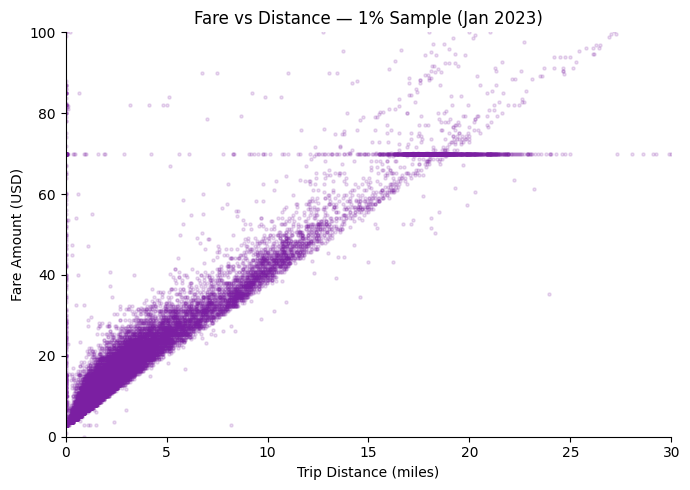

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount", "trip_distance"]
)
df = df[df["fare_amount"] > 0].copy()
df = df.set_index("tpep_pickup_datetime").sort_index()

# --- Strategy 1: time-based resampling (3 M rows → 744 points) ---
hourly_mean = df[["fare_amount","trip_distance"]].resample("1h").mean()

fig, ax = plt.subplots(figsize=(12, 4))
hourly_mean["fare_amount"].plot(ax=ax, color="#1565C0", linewidth=1)
ax.set_title("Hourly Mean Fare — January 2023")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Fare (USD)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/hourly_mean_fare.png", dpi=150)
plt.show()

print(f"Raw rows: {len(df):,} → resampled: {len(hourly_mean):,}")

# --- Strategy 2: random sampling for scatter plots ---
sample = df.reset_index().sample(frac=0.01, random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    sample["trip_distance"], sample["fare_amount"],
    alpha=0.15, s=5, color="#7B1FA2"
)
ax.set_xlim(0, 30); ax.set_ylim(0, 100)
ax.set_xlabel("Trip Distance (miles)")
ax.set_ylabel("Fare Amount (USD)")
ax.set_title("Fare vs Distance — 1% Sample (Jan 2023)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/fare_distance.png", dpi=150)
plt.show()

## Interactive Visualisation with hvPlot
### Introduction to hvPlot

In [2]:
import pandas as pd
import hvplot.pandas   # registers .hvplot accessor on DataFrames

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "trip_distance", "payment_type"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"] = df["tpep_pickup_datetime"].dt.hour

print(type(df.hvplot))
# <class 'hvplot.plotting.core.hvPlotTabular'>

<class 'hvplot.plotting.core.hvPlotTabular'>


### hvPlot with Pandas DataFrames

In [1]:
import pandas as pd
import hvplot.pandas

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "tip_amount", "trip_distance", "payment_type"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"]    = df["tpep_pickup_datetime"].dt.hour
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"] * 100).round(1)

hourly = df.groupby("hour").agg(
    n_trips  =("fare_amount","count"),
    avg_fare =("fare_amount","mean"),
).reset_index()

# Interactive line chart
line_plot = hourly.hvplot.line(
    x="hour", y="avg_fare",
    title="Mean Fare by Hour — January 2023",
    xlabel="Hour of Day", ylabel="Mean Fare (USD)",
    color="#1565C0", line_width=2.5,
    width=700, height=350
)

# Interactive bar chart
bar_plot = hourly.hvplot.bar(
    x="hour", y="n_trips",
    title="Trip Count by Hour",
    xlabel="Hour of Day", ylabel="Trips",
    color="#43A047",
    width=700, height=350
)

layout = (line_plot + bar_plot).cols(1)
layout

:Layout
   .Curve.I :Curve   [hour]   (avg_fare)
   .Bars.I  :Bars   [hour]   (n_trips)

In [4]:
line_plot

:Curve   [hour]   (avg_fare)

In [5]:
bar_plot

:Bars   [hour]   (n_trips)

**Save interactive plots:**

In [2]:
import holoviews as hv
hv.save(line_plot, "../outputs/hv_line_plot.html")
hv.save(bar_plot, "../outputs/hv_bar_plot.html")

In [6]:
# Scatter plot: fare vs distance, coloured by payment type
sample = df.sample(50_000, random_state=42)

scatter_plot = sample.hvplot.scatter(
    x="trip_distance", y="fare_amount",
    by="payment_type",
    xlim=(0, 25), ylim=(0, 80),
    alpha=0.3, size=4,
    title="Fare vs Distance by Payment Type",
    xlabel="Distance (miles)", ylabel="Fare (USD)",
    width=700, height=400
)
# save the interactive plot
hv.save(scatter_plot, "../outputs/hv_scatter_plot.html")
# Display the plot
scatter_plot

:NdOverlay   [payment_type]
   :Scatter   [trip_distance]   (fare_amount)

### hvPlot with Dask for large data

In [3]:
import dask.dataframe as dd
import hvplot.dask
import holoviews as hv

# Read all 12 months lazily with Dask
ddf = dd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-*.parquet",
    columns=["trip_distance", "fare_amount"]
)
ddf = ddf[(ddf["trip_distance"] > 0) & (ddf["fare_amount"] > 0)]

# hexbin with Datashader — renders 38 M points instantly
hexbin_plot = ddf.hvplot.hexbin(
    x="trip_distance", y="fare_amount",
    xlim=(0, 20), ylim=(0, 80),
    colorbar=True, logz=True,
    title="Fare vs Distance — Full Year 2023 (Datashader)",
    xlabel="Trip Distance (miles)",
    ylabel="Fare Amount (USD)",
    width=650, height=450
)

# save the interactive plot
hv.save(hexbin_plot, "../outputs/hv_hexbin_plot.html")

hexbin_plot

:HexTiles   [trip_distance,fare_amount]

### Linked and interactive plots

In [17]:
import pandas as pd
import hvplot.pandas

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "tip_amount", "trip_distance"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"]    = df["tpep_pickup_datetime"].dt.hour
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"] * 100).round(1)

hourly = df.groupby("hour").agg(
    avg_fare   =("fare_amount", "mean"),
    avg_tip_pct=("tip_pct",    "mean"),
).reset_index()

# Side-by-side layout with +
fare_plot = hourly.hvplot.line(
    x="hour", y="avg_fare", title="Mean Fare by Hour",
    ylabel="Fare (USD)", color="#1565C0", width=400, height=300
)
tip_plot = hourly.hvplot.line(
    x="hour", y="avg_tip_pct", title="Mean Tip % by Hour",
    ylabel="Tip (%)", color="#C62828", width=400, height=300
)

fare_plot + tip_plot

:Layout
   .Curve.I  :Curve   [hour]   (avg_fare)
   .Curve.II :Curve   [hour]   (avg_tip_pct)

**Save the combined plots:**

In [5]:
fare_tip_plots = (fare_plot + tip_plot)
hv.save(fare_tip_plots, "../outputs/hv_fare_tip_plots.html")

In [7]:
# Overlay mean and 95th-percentile fare with *
p95 = df.groupby("hour")["fare_amount"].quantile(0.95).reset_index()
p95.columns = ["hour", "p95_fare"]

mean_line = hourly.hvplot.line(
    x="hour", y="avg_fare", label="Mean",
    color="#1565C0", width=700, height=350
)
p95_line = p95.hvplot.line(
    x="hour", y="p95_fare", label="95th pct",
    color="#FF7043", line_dash="dashed"
)

mean_p95_line_plot = (mean_line * p95_line).opts(
    title="Fare by Hour — Mean vs 95th Percentile",
    xlabel="Hour of Day", ylabel="Fare (USD)"
)

hv.save(mean_p95_line_plot, "../outputs/hv_mean_p95_line_plot.html")
mean_p95_line_plot


:Overlay
   .Curve.Mean       :Curve   [hour]   (avg_fare)
   .Curve.A_95th_pct :Curve   [hour]   (p95_fare)

### Customisation and styling

In [19]:
import pandas as pd
import hvplot.pandas
import holoviews as hv

hv.extension('bokeh')

# Re-load and process the data (important!)
df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount", "trip_distance"]
)

# Filter
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()

# Extract hour and create the aggregation
df["hour"] = df["tpep_pickup_datetime"].dt.hour

hourly = df.groupby("hour").agg(
    n_trips=("fare_amount", "count"),
    avg_fare=("fare_amount", "mean")
).reset_index()          # <-- This makes 'hour' a column

print("Columns in hourly:", hourly.columns.tolist())
print(hourly.head())

Columns in hourly: ['hour', 'n_trips', 'avg_fare']
   hour  n_trips   avg_fare
0     0    82723  19.840308
1     1    58102  17.972205
2     2    40715  16.966450
3     3    26354  17.996856
4     4    16816  22.518931


In [20]:
styled = hourly.hvplot.bar(
    x="hour", 
    y="n_trips",
    title="NYC Taxi Trips by Hour — January 2023",
    xlabel="Hour of Day", 
    ylabel="Number of Trips",
    color="#1976D2", 
    alpha=0.85,
    width=720, 
    height=380,
    tools=["hover"],
    hover_tooltips=[
        ("Hour", "@hour"),
        ("Trips", "@n_trips{0,0}")
    ]
).opts(toolbar="above", show_grid=True)

styled

:Bars   [hour]   (n_trips)

### Performance considerations

## Grammar of Graphics with Lets-Plot

### Introduction to Lets-Plot

In [22]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

from lets_plot import *
LetsPlot.setup_html()   # configure HTML rendering in Jupyter

### Core concepts: ggplot, aes, and geoms

In [1]:
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "trip_distance", "payment_type"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["payment_label"] = df["payment_type"].map(
    {1:"Credit Card", 2:"Cash", 3:"No Charge",
     4:"Dispute",     0:"Unknown"}
)

# Hourly mean fare — a complete Grammar of Graphics spec
hourly = df.groupby("hour")["fare_amount"].mean().reset_index()
hourly.columns = ["hour", "avg_fare"]

p = (
    ggplot(hourly, aes(x="hour", y="avg_fare"))
    + geom_line(color="#1565C0", size=1.5)
    + geom_point(color="#1565C0", size=3)
    + labs(
        title="Mean Fare by Hour — January 2023",
        x="Hour of Day",
        y="Mean Fare (USD)"
    )
    + theme_light()
    + ggsize(700, 350)
)

p

**Save the plot**

In [43]:
from pathlib import Path

output_path = Path("../outputs/").resolve()

plot_html = "ggplot_hourly_mean_fare.html"
# Save the interactive plot as HTML
ggsave(p, filename=str(output_path / plot_html))

# Save as PNG (scaled)
plot_png = "ggplot_hourly_mean_fare.png"
ggsave(p, filename=str(output_path /plot_png), scale=2)

'E:\\project-workspace\\quarto-book\\data-analysis-model-book\\data-analysis\\outputs\\ggplot_hourly_mean_fare.png'

### Layers, aesthetics, and geom types

In [5]:
# Bar chart: trip count by payment type
payment_hourly = (
    df.groupby(["hour","payment_label"])
    .size().reset_index(name="n_trips")
)

p_bar = (
    ggplot(payment_hourly,
           aes(x="hour", y="n_trips", fill="payment_label"))
    + geom_bar(stat="identity", position="stack")
    + scale_fill_brewer(type="qual", palette="Set2",
                        name="Payment Type")
    + labs(title="Trips by Hour and Payment Type",
           x="Hour of Day", y="Number of Trips")
    + theme_light()
    + ggsize(750, 380)
)

# Save as PNG (scaled)
bar_plot_png = "ggplot_bar_trip_payment.png"
ggsave(p_bar, filename=str(output_path /bar_plot_png), scale=2)

p_bar

In [6]:
# Scatter: fare vs distance (1% sample)
sample = df.sample(30_000, random_state=42)

p_scatter = (
    ggplot(sample, aes(x="trip_distance", y="fare_amount",
                       color="payment_label"))
    + geom_point(alpha=0.3, size=1.5)
    + xlim(0, 25)
    + ylim(0, 80)
    + scale_color_brewer(type="qual", palette="Dark2",
                         name="Payment Type")
    + labs(title="Fare vs Distance by Payment Type",
           x="Distance (miles)", y="Fare (USD)")
    + theme_light()
    + ggsize(700, 420)
)

# Save as PNG (scaled)
scatter_plot_png = "ggplot_scatter_fare_distance.png"
ggsave(p_scatter, filename=str(output_path /scatter_plot_png), scale=2)

p_scatter

### Visualising hierarchical data with Lets-Plot

In [29]:
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

borough_summary = (
    pd.read_parquet(
        "../data/taxi/yellow_tripdata_2023-01.parquet",
        columns=["fare_amount", "tip_amount", "PULocationID"]
    )
    .merge(
        pd.read_csv("../data/taxi/taxi_zone_lookup.csv")[["LocationID", "Borough"]],
        left_on="PULocationID", right_on="LocationID",
        how="left"
    )
    .groupby("Borough")
    .agg(
        n_trips=("fare_amount", "count"),
        avg_fare=("fare_amount", "mean"),
        avg_tip=("tip_amount", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("n_trips", ascending=False)
    .assign(
        n_trips_M=lambda d: d["n_trips"] / 1_000_000,
        zero=0.0   # <-- the fix: baseline as a named float column
    )
)

p_lollipop = (
    ggplot(borough_summary, aes(x="n_trips_M", y="Borough"))
    + geom_segment(aes(x="zero", xend="n_trips_M", y="Borough", yend="Borough"),
                   color="#90A4AE", size=1)
    + geom_point(aes(color="avg_fare"), size=5)
    + scale_color_continuous(low="#81D4FA", high="#01579B")
    + labs(
        title="NYC Taxi — Trips per Borough (January 2023)",
        x="Number of Trips (millions)",
        y="Borough",
        color="Mean Fare"
    )
    + theme_light()
    + ggsize(700, 340)
)

# Save as PNG (scaled)
lollipop_png = "ggplot_lollipop_trips_borough.png"
ggsave(p_lollipop, filename=str(output_path /lollipop_png), scale=2)

p_lollipop

### Tree structures and relationships

In [40]:
import pandas as pd
import numpy as np
from lets_plot import *
LetsPlot.setup_html()

# ── data ──────────────────────────────────────────────────────────────────
zones = pd.read_csv("../data/taxi/taxi_zone_lookup.csv")
trips = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["fare_amount", "PULocationID"]
)
trips = trips[trips["fare_amount"] > 0]

zone_trips = (
    trips.merge(zones[["LocationID", "Borough", "Zone"]],
                left_on="PULocationID", right_on="LocationID", how="left")
    .groupby(["Borough", "Zone"])
    .size().reset_index(name="n_trips")
    .sort_values(["Borough", "n_trips"], ascending=[True, False])
)

top_zones = zone_trips.groupby("Borough").head(2).reset_index(drop=True)
boroughs  = top_zones["Borough"].unique()
# ── layout: wider spacing ──────────────────────────────────────────────────
n_boroughs = len(boroughs)
# Multiply x positions by 2 to spread everything out
nodes = [{"label": "NYC", "x": n_boroughs, "y": 2,
          "type": "root", "n_trips": trips.shape[0]}]
edges = []

for i, b in enumerate(boroughs):
    bx = i * 2                          # borough spacing: 0, 2, 4, 6, 8 ...
    nodes.append({"label": b, "x": bx, "y": 1,
                  "type": "borough",
                  "n_trips": int(top_zones[top_zones["Borough"]==b]["n_trips"].sum())})
    edges.append({"x": n_boroughs, "y": 2, "xend": bx, "yend": 1})
    zones_b = top_zones[top_zones["Borough"]==b].reset_index(drop=True)
    for j, (_, row) in enumerate(zones_b.iterrows()):
        zx = bx + (j - 0.5) * 1.2      # zone spacing: wider offset
        nodes.append({"label": row["Zone"][:14],
                      "x": zx, "y": 0,
                      "type": "zone",
                      "n_trips": int(row["n_trips"])})
        edges.append({"x": bx, "y": 1, "xend": zx, "yend": 0})

nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)
nodes_df["size_val"] = nodes_df["n_trips"].clip(
    upper=nodes_df[nodes_df["type"] != "root"]["n_trips"].max()
)

labels_above = nodes_df[nodes_df["type"].isin(["root", "borough"])]
labels_below = nodes_df[nodes_df["type"] == "zone"]

p_tree = (
    ggplot()
    + geom_segment(
          aes(x="x", y="y", xend="xend", yend="yend"),
          data=edges_df,
          color="#BDBDBD", size=0.8
      )
    + geom_point(
          aes(x="x", y="y", size="size_val", color="type"),
          data=nodes_df,
          alpha=0.85
      )
    + geom_text(                        # root + borough labels: above the node
          aes(x="x", y="y", label="label"),
          data=labels_above,
          vjust=-1.4,
          size=9,
          color="#424242"
      )
    + geom_text(                        # zone labels: below the node, angled
          aes(x="x", y="y", label="label"),
          data=labels_below,
          vjust=2.2,                    # below
          angle=30,                     # slight angle to reduce overlap
          size=8,
          color="#424242"
      )
    + scale_color_manual(
          values={"root": "#1565C0", "borough": "#43A047", "zone": "#FB8C00"},
          guide="none"
      )
    + scale_size(range=[4, 16], guide="none")
    + coord_cartesian(ylim=[-1.5, 2.6])  # extra room below for angled labels
    + labs(title="NYC Taxi — Borough → Zone Trip Tree")
    + theme_void()
    + ggsize(1200, 560)
)

# Save as PNG (scaled)
tree_png = "ggplot_borough_trip_tree.png"
ggsave(p_tree, filename=str(output_path /tree_png), scale=2)

p_tree

### Network graph visualisation

In [45]:
import pandas as pd
import numpy as np
import networkx as nx
from lets_plot import *
LetsPlot.setup_html()

# Borough-to-borough flow
zones = pd.read_csv("../data/taxi/taxi_zone_lookup.csv")
trips = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["PULocationID","DOLocationID"]
)

flow = (
    trips
    .merge(zones[["LocationID","Borough"]].rename(
               columns={"LocationID":"PULocationID",
                        "Borough":"PUBorough"}),
           on="PULocationID")
    .merge(zones[["LocationID","Borough"]].rename(
               columns={"LocationID":"DOLocationID",
                        "Borough":"DOBorough"}),
           on="DOLocationID")
    .query("PUBorough != DOBorough")
    .groupby(["PUBorough","DOBorough"])
    .size().reset_index(name="n_trips")
)

G = nx.from_pandas_edgelist(
    flow, source="PUBorough", target="DOBorough",
    edge_attr="n_trips", create_using=nx.DiGraph()
)
pos = nx.circular_layout(G)

# Build node and edge DataFrames
node_df = pd.DataFrame([
    {"borough": n,
     "x": pos[n][0], "y": pos[n][1],
     "degree": G.degree(n)}
    for n in G.nodes()
])

edge_df = pd.DataFrame([
    {"x":   pos[u][0], "y":   pos[u][1],
     "xend":pos[v][0], "yend":pos[v][1],
     "weight": d["n_trips"]}
    for u, v, d in G.edges(data=True)
])
edge_df["weight_norm"] = (
    edge_df["weight"] / edge_df["weight"].max() * 3
).clip(0.3)

# Scale positions inward so labels don't hit the canvas edge
scale = 0.7
node_df["x"] = node_df["x"] * scale
node_df["y"] = node_df["y"] * scale
edge_df["x"]    = edge_df["x"]    * scale
edge_df["y"]    = edge_df["y"]    * scale
edge_df["xend"] = edge_df["xend"] * scale
edge_df["yend"] = edge_df["yend"] * scale

p_net = (
    ggplot()
    + geom_segment(
          aes(x="x", y="y", xend="xend", yend="yend",
              size="weight_norm"),
          data=edge_df,
          color="#90A4AE", alpha=0.7, show_legend=False
      )
    + geom_point(
          aes(x="x", y="y", size="degree"),
          data=node_df,
          color="#1565C0", alpha=0.9, show_legend=False
      )
    + geom_text(
          aes(x="x", y="y", label="borough"),
          data=node_df,
          vjust=-1.4, size=10, color="#212121", fontface="bold"
      )
    + coord_cartesian(xlim=[-1.3, 1.3], ylim=[-1.3, 1.3])  # padding for labels
    + labs(title="NYC Taxi — Inter-Borough Passenger Flow (January 2023)")
    + theme_void()
    + ggsize(720, 560)
)

# Save as PNG (scaled)
net_png = "ggplot_passenger_flow.png"
ggsave(p_net, filename=str(output_path /net_png), scale=2)

p_net

### Faceting, theming, and export

In [1]:
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime","fare_amount",
             "tip_amount","payment_type"]
)
df = df[(df["fare_amount"] > 0)].copy()
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"] * 100).round(1)
df["payment_label"] = df["payment_type"].map(
    {1:"Credit Card",2:"Cash",3:"No Charge",4:"Dispute",0:"Unknown"}
)
# Keep two main types for clarity
df = df[df["payment_label"].isin(["Credit Card","Cash"])]
hourly = (
    df.groupby(["hour","payment_label"])
    .agg(avg_tip_pct=("tip_pct","mean"))
    .reset_index()
)

# Faceted line chart: one panel per payment type
p_facet = (
    ggplot(hourly, aes(x="hour", y="avg_tip_pct",
                       color="payment_label"))
    + geom_line(size=1.5)
    + geom_point(size=2.5)
    + facet_wrap("payment_label", ncol=2)
    + scale_color_manual(
          values={"Credit Card":"#1565C0","Cash":"#2E7D32"},
          guide="none"
      )
    + labs(title="Mean Tip % by Hour — Credit Card vs Cash",
           x="Hour of Day", y="Mean Tip (%)")
    + theme_grey()
    + ggsize(800, 320)
)
p_facet

In [3]:
# Export to PNG and SVG
p_facet.to_png("../outputs/ggplot_taxi_facet_tip.png", scale=2)
p_facet.to_svg("../outputs/ggplot_taxi_facet_tip.svg")

'E:\\project-workspace\\quarto-book\\data-analysis-model-book\\data-analysis\\outputs\\ggplot_taxi_facet_tip.svg'

In [4]:
ggsave(p_facet, "../outputs/ggplot_taxi_facet_tip.pdf")

'E:\\project-workspace\\quarto-book\\data-analysis-model-book\\data-analysis\\notebooks\\outputs\\taxi_facet_tip.pdf'

In [5]:
p_facet.to_svg("../outputs/ggplot_taxi_facet_tip.pdf")

'E:\\project-workspace\\quarto-book\\data-analysis-model-book\\data-analysis\\outputs\\ggplot_taxi_facet_tip.pdf'

## Categorical Visualisation with PyWaffle

### Creating waffle charts

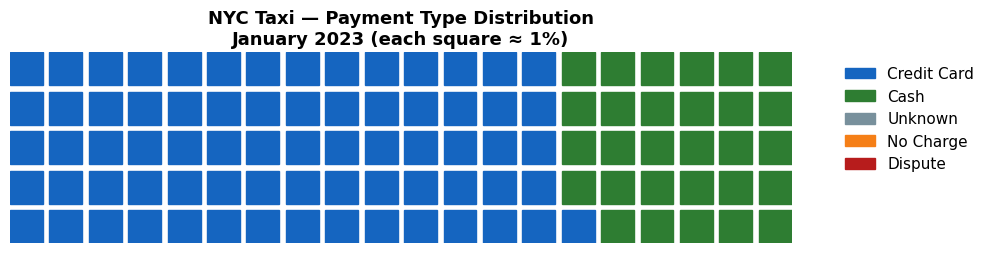

In [1]:
import matplotlib.pyplot as plt
from pywaffle import Waffle

payment_counts = {
    "Credit Card": 2102352,
    "Cash":         844167,
    "Unknown":        7604,
    "No Charge":      4609,
    "Dispute":        1948,
}

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=payment_counts,
    colors=["#1565C0","#2E7D32","#78909C","#F57F17","#B71C1C"],
    legend={
        "loc":            "upper left",
        "bbox_to_anchor": (1.05, 1),
        "fontsize":       11,
        "framealpha":     0,
    },
    title={
        "label": "NYC Taxi — Payment Type Distribution\n"
                 "January 2023 (each square ≈ 1%)",
        "fontsize": 13,
        "fontweight": "bold",
    },
    figsize=(10, 4),
)
plt.tight_layout()
plt.savefig("../outputs/waffle_taxi_payment.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Customising layouts and colours

In [ ]:
from patch_pywaffle import patch_pywaffle 
patch_pywaffle()

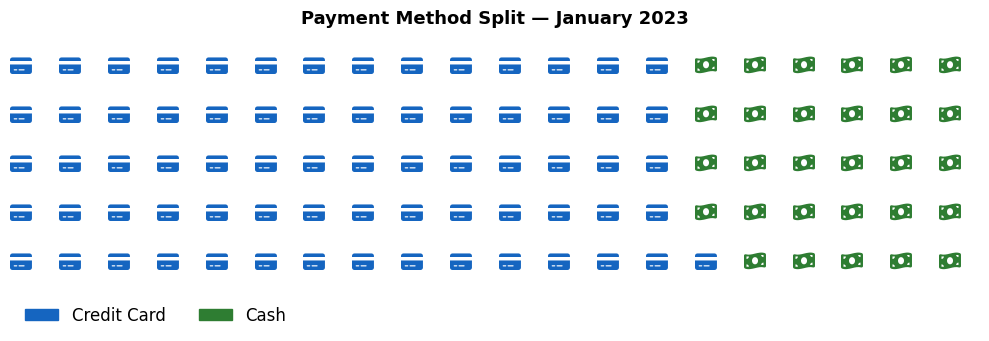

In [2]:
import matplotlib.pyplot as plt
from pywaffle import Waffle
import warnings

warnings.filterwarnings("ignore", message="Tight layout")

data = {"Credit Card": 71, "Cash": 29}

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=data,
    colors=["#1565C0", "#2E7D32"],
    icons=["credit-card", "money-bill-wave"],
    icon_legend=False,
    font_size=14,
    legend={
        "loc":            "lower left",
        "bbox_to_anchor": (0, -0.3),
        "ncol":           2,
        "fontsize":       12,
        "framealpha":     0,
    },
    title={
        "label": "Payment Method Split — January 2023",
        "fontsize": 13, "fontweight": "bold"
    },
    figsize=(10, 3.5),
)
plt.tight_layout()
plt.show()

**The version for the book:**

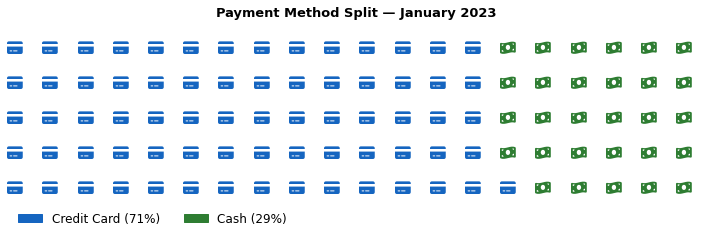

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import warnings
from pywaffle import Waffle

mpl.rcParams["figure.dpi"] = 72
warnings.filterwarnings("ignore", message="Tight layout")

data = {"Credit Card": 71, "Cash": 29}

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=data,
    colors=["#1565C0", "#2E7D32"],
    icons=["credit-card", "money-bill-wave"],
    icon_style="solid",
    icon_legend=True,
    font_size=14,
    figsize=(10, 3.5),
    dpi=72,
)

ax = fig.gca()
patches = [
    mpatches.Patch(color="#1565C0", label="Credit Card (71%)"),
    mpatches.Patch(color="#2E7D32", label="Cash (29%)"),
]
ax.legend(handles=patches, loc="upper left", bbox_to_anchor=(0, -0.05),
          ncol=2, fontsize=12, framealpha=0)
ax.set_title("Payment Method Split — January 2023",
             fontsize=13, fontweight="bold")

plt.savefig("../outputs/waffle_payment_methods.png", dpi=150)
plt.show()

**Starting location and block arrangement**

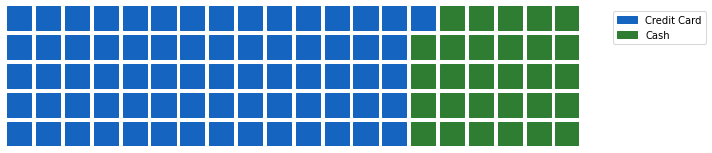

In [5]:
import matplotlib.pyplot as plt
from pywaffle import Waffle

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values={"Credit Card": 71, "Cash": 29},
    colors=["#1565C0", "#2E7D32"],
    starting_location="NW",           # fill from top-left
    block_arranging_style="snake",
    legend={"loc": "upper left", "bbox_to_anchor": (1.05, 1)},
    figsize=(10, 3),
)
plt.savefig("../outputs/waffle_block_arrange.png", dpi=150)
plt.show()

### Comparing categories effectively

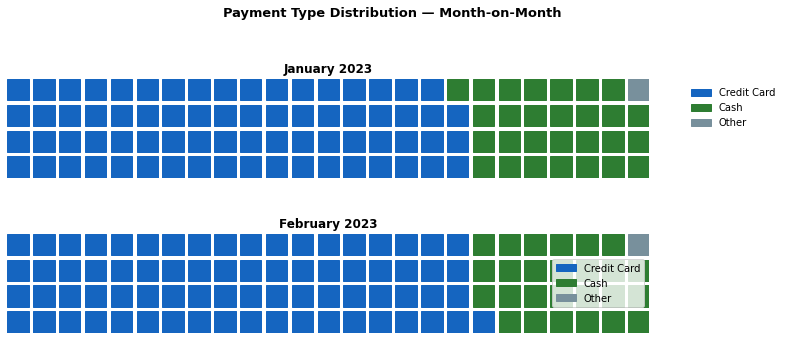

In [6]:
import matplotlib.pyplot as plt
from pywaffle import Waffle

jan = {"Credit Card": 71, "Cash": 28, "Other": 1}
feb = {"Credit Card": 73, "Cash": 26, "Other": 1}
colors = ["#1565C0", "#2E7D32", "#78909C"]

fig = plt.figure(
    FigureClass=Waffle,
    plots={
        211: {
            "values": jan,
            "colors": colors,
            "title": {"label": "January 2023",
                      "fontsize": 12, "fontweight": "bold"},
            "legend": {"loc": "upper left",
                       "bbox_to_anchor": (1.05, 1),
                       "fontsize": 10, "framealpha": 0},
        },
        212: {
            "values": feb,
            "colors": colors,
            "title": {"label": "February 2023",
                      "fontsize": 12, "fontweight": "bold"},
        },
    },
    rows=4,
    columns=25,
    figsize=(11, 5),
)
fig.suptitle(
    "Payment Type Distribution — Month-on-Month",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/waffle_taxi_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Use cases in dashboards

In [7]:
import matplotlib.pyplot as plt
from pywaffle import Waffle

# Panel 1 — payment type split
wf1 = plt.figure(
    FigureClass=Waffle, rows=5, columns=20,
    values={"Credit": 71, "Cash": 29},
    colors=["#1565C0","#2E7D32"],
    title={"label":"Payment Split","fontsize":11},
    figsize=(6, 2.5)
)
wf1.savefig("../outputs/waffle_payment.png",
            dpi=150, bbox_inches="tight")
plt.close(wf1)

# Panel 2 — borough split (Manhattan vs rest)
wf2 = plt.figure(
    FigureClass=Waffle, rows=5, columns=20,
    values={"Manhattan":88, "Other":12},
    colors=["#E53935","#90A4AE"],
    title={"label":"Borough Split","fontsize":11},
    figsize=(6, 2.5)
)
wf2.savefig("../outputs/waffle_borough.png",
            dpi=150, bbox_inches="tight")
plt.close(wf2)

print("Dashboard panels saved.")

Dashboard panels saved.


## Comparing Advanced Visualisation Libraries

### hvPlot vs Matplotlib vs Seaborn vs Lets-Plot

### Performance and scalability

In [3]:
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime", "fare_amount",
             "tip_amount", "payment_type"]
)
df = df[(df["fare_amount"] > 0)].copy()
# Automatically sample large datasets before rendering
p = (
    ggplot(df, aes(x="tip_amount", y="fare_amount"))
    + geom_point(sampling=sampling_random(n=50_000, seed=42),
                 alpha=0.2, size=1.5, color="#7B1FA2")
    + xlim(0, 25) + ylim(0, 80)
    + labs(title="Fare vs Tip — Auto-Sampled 50k Points")
    + theme_light()
    + ggsize(700, 420)
)
p.to_png("../outputs/ggplot_auto_sampled.png", scale=2)
p

## Case Studies

### Case study 1 — Interactive hourly analysis

In [5]:
import pandas as pd
import hvplot.pandas
import holoviews as hv

hv.extension("bokeh")

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["tpep_pickup_datetime","fare_amount",
             "tip_amount","trip_distance","payment_type"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["hour"]    = df["tpep_pickup_datetime"].dt.hour
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"] * 100).round(1)

hourly = df.groupby("hour").agg(
    n_trips    =("fare_amount","count"),
    avg_fare   =("fare_amount","mean"),
    avg_tip_pct=("tip_pct","mean"),
    avg_dist   =("trip_distance","mean"),
).reset_index()

trips_plot = hourly.hvplot.bar(
    x="hour", y="n_trips",    title="Trip Volume",
    color="#1976D2", height=260, width=380, tools=["hover"]
)
fare_plot = hourly.hvplot.line(
    x="hour", y="avg_fare",   title="Mean Fare (USD)",
    color="#C62828", height=260, width=380, line_width=2.5
)
tip_plot = hourly.hvplot.line(
    x="hour", y="avg_tip_pct",title="Mean Tip %",
    color="#2E7D32", height=260, width=380, line_width=2.5
)
dist_plot = hourly.hvplot.area(
    x="hour", y="avg_dist",   title="Mean Distance (mi)",
    color="#6A1B9A", alpha=0.4, height=260, width=380
)

dashboard = (trips_plot + fare_plot + tip_plot + dist_plot).cols(2)
dashboard.opts(title="NYC Taxi — Hourly Profile Dashboard")
hvplot.save(dashboard, "../outputs/hvplot_taxi_hourly_dashboard.html")
dashboard

:Layout
   .Bars.I   :Bars   [hour]   (n_trips)
   .Curve.I  :Curve   [hour]   (avg_fare)
   .Curve.II :Curve   [hour]   (avg_tip_pct)
   .Area.I   :Area   [hour]   (avg_dist)

### Case study 2 — Category distribution visualisation

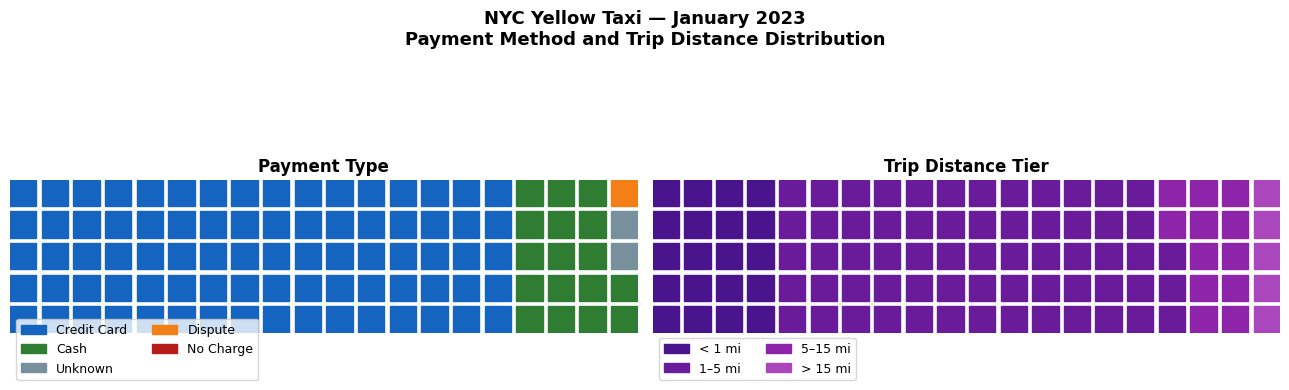

In [8]:
import matplotlib.pyplot as plt
from pywaffle import Waffle
import pandas as pd

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["fare_amount","trip_distance","payment_type"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()

payment = (
    df["payment_type"]
    .map({1:"Credit Card",2:"Cash",3:"No Charge",
          4:"Dispute",0:"Unknown"})
    .value_counts(normalize=True).mul(100)
    .round(0).astype(int).to_dict()
)

def tier(d):
    if d < 1: return "< 1 mi"
    elif d < 5: return "1–5 mi"
    elif d < 15: return "5–15 mi"
    else: return "> 15 mi"

distance = (
    df["trip_distance"].apply(tier)
    .value_counts(normalize=True).mul(100)
    .round(0).astype(int)
    .reindex(["< 1 mi","1–5 mi","5–15 mi","> 15 mi"])
    .to_dict()
)

fig = plt.figure(
    FigureClass=Waffle,
    plots={
        121: {"values": payment,
              "colors": ["#1565C0","#2E7D32","#78909C",
                         "#F57F17","#B71C1C"],
              "title": {"label":"Payment Type",
                        "fontsize":12,"fontweight":"bold"},
              "legend": {"loc":"lower left",
                         "bbox_to_anchor":(0,-0.35),
                         "ncol":2,"fontsize":9}},
        122: {"values": distance,
              "colors": ["#4A148C","#6A1B9A","#8E24AA","#AB47BC"],
              "title": {"label":"Trip Distance Tier",
                        "fontsize":12,"fontweight":"bold"},
              "legend": {"loc":"lower left",
                         "bbox_to_anchor":(0,-0.35),
                         "ncol":2,"fontsize":9}},
    },
    rows=5, columns=20,
    figsize=(13, 4),
)
fig.suptitle(
    "NYC Yellow Taxi — January 2023\n"
    "Payment Method and Trip Distance Distribution",
    fontsize=13, fontweight="bold", y=1.05
)
plt.savefig("../outputs/waffle_taxi_casestudy.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Case study 3 — Hierarchical data exploration with Lets-Plot

In [25]:
import pandas as pd
from lets_plot import *
from lets_plot import gggrid
LetsPlot.setup_html()

df = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["fare_amount","tip_amount",
             "trip_distance","PULocationID"]
)
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)].copy()
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"] * 100).round(1)

zones = pd.read_csv("../data/taxi/taxi_zone_lookup.csv")
df = df.merge(zones[["LocationID","Borough"]],
              left_on="PULocationID",
              right_on="LocationID", how="left")

# Summary
borough_summary = (
    df.groupby("Borough")
    .agg(n_trips =("fare_amount","count"),
         avg_fare=("fare_amount","mean"),
         avg_tip =("tip_pct","mean"))
    .round(2).reset_index()
    .sort_values("n_trips", ascending=False)
    .assign(
        n_trips_M=lambda d: d["n_trips"] / 1_000_000,  # ← pre-divide for axis
        zero=0.0                                         # ← fix ClassCastException
    )
)

# Resize for single-column stacking
p1_tall = (
    ggplot(borough_summary, aes(x="n_trips_M", y="Borough"))
    + geom_segment(aes(x="zero", xend="n_trips_M",
                       y="Borough", yend="Borough"),
                   color="#90A4AE", size=1.2)
    + geom_point(aes(color="avg_fare"), size=6)
    + scale_color_gradient(low="#81D4FA", high="#01579B",
                            name="Mean Fare")
    + labs(title="Trip Volume per Borough",
           x="Trips (millions)", y="Borough")
    + theme_light()
    + ggsize(1000, 300)
)

p2_tall = (
    ggplot(sample, aes(x="Borough", y="fare_amount"))
    + geom_boxplot(
          outlier_alpha=0.1, outlier_size=1,
          fill="#81D4FA", color="#1565C0",
          show_legend=False
      )
    + ylim(0, 80)
    + labs(title="Fare Distribution by Borough",
           x="Borough", y="Fare (USD)")
    + theme_light()
    + ggsize(1000, 300)
)

p3_wide = (
    ggplot(tier_borough, aes(x="dist_tier", y="avg_tip",
                              fill="dist_tier"))
    + geom_bar(stat="identity", show_legend=False)
    + facet_wrap("Borough", ncol=4)
    + scale_fill_brewer(type="seq", palette="Blues",
                        direction=-1, guide="none")
    + labs(title="Mean Tip % by Distance Tier and Borough",
           x="Distance Tier", y="Mean Tip (%)")
    + theme_light()
    + ggsize(1000, 360)
)
# Combine into a 3×1 grid
grid = gggrid([p1_tall, p2_tall, p3_wide], ncol=1)
# save the charts
grid.to_png("../outputs/ggplot_case-study.png", scale=2)
grid.to_html("../outputs/ggplot_case-study.html")
grid.show()